# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('emp_automovel.csv')

In [3]:
dados

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [4]:
x = dados.drop('inadimplente', axis=1)
y = dados['inadimplente']

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
modelo = DecisionTreeClassifier()
modelo.fit(x, y)
modelo.score(x, y) # Model Accuracy

1.0

<img src="https://bing.com/th/id/BCO.9377068b-816d-4d1d-835b-bc93dbfbd602.png" width="350"/>

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x, x_test, y, y_test = train_test_split(x, y, test_size=0.15, stratify=y, random_state=5)
x_train, x_val, y_train, y_val = train_test_split(x, y, stratify=y, random_state=5)

In [9]:
modelo = DecisionTreeClassifier()
modelo.fit(x_train, y_train)
print(f'Accuracy Train: {modelo.score(x_train, y_train)}')
print(f'Accuracy validation: {modelo.score(x_val, y_val)}')

Accuracy Train: 1.0
Accuracy validation: 0.8474871526870482


In [10]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_train, y_train)
print(f'Accuracy Train: {modelo.score(x_train, y_train)}')
print(f'Accuracy validation: {modelo.score(x_val, y_val)}')

Accuracy Train: 0.9205574912891986
Accuracy validation: 0.9060186394913335


### Avaliando o Modelo

In [11]:
from sklearn.metrics import confusion_matrix

In [12]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
matriz_confusao

array([[10361,   118],
       [  961,    41]])

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

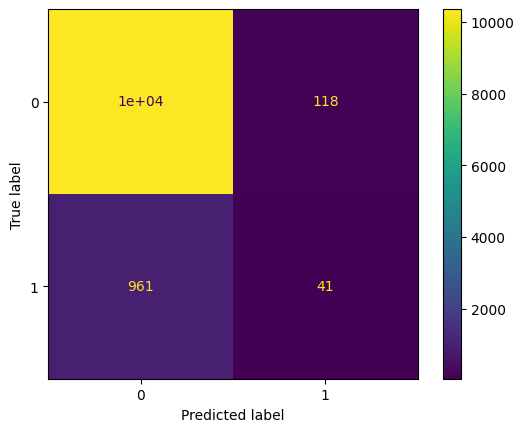

In [14]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualizacao.plot();

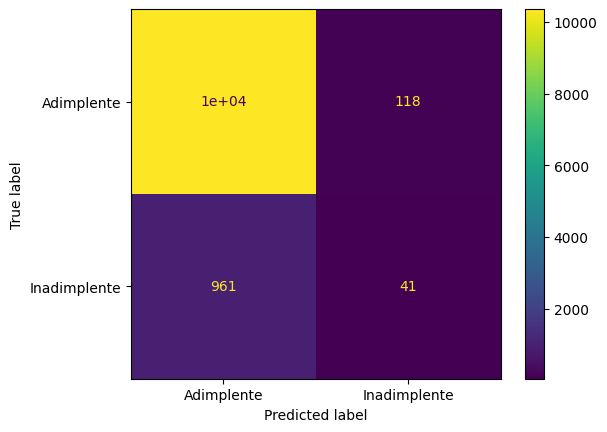

In [15]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

### Desafio

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
modelo = RandomForestClassifier(max_depth=10)
modelo.fit(x_train, y_train)
print(f'Accuracy train: {modelo.score(x_train, y_train)}')
print(f'Accuracy validation: {modelo.score(x_val, y_val)}')

Accuracy train: 0.9151567944250871
Accuracy validation: 0.9129866736347008


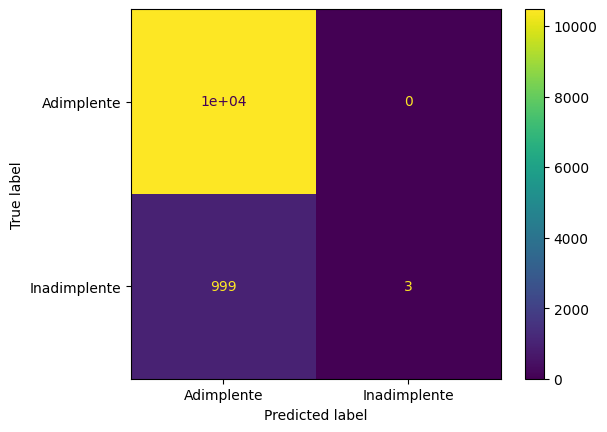

In [18]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                                      display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

<img src="https://bing.com/th/id/BCO.46fe0be0-eb48-45c8-8978-155b4cef8529.png" width="350"/>

### Principais Métricas

| Métrica     | O que mede | Quando usar | Exemplo prático |
|-------------|------------|-------------|------------------|
| **Acurácia** | Proporção de acertos totais | Quando as classes estão balanceadas | Reconhecimento de dígitos manuscritos |
| **Recall** | Capacidade de identificar corretamente os positivos reais | Quando é grave perder um positivo (falso negativo) | Diagnóstico de doenças graves |
| **Precisão** | Proporção de positivos previstos que são realmente positivos | Quando é grave classificar um negativo como positivo (falso positivo) | Seleção de ações financeiras |
| **F1-Score** | Equilíbrio entre precisão e recall | Quando há desequilíbrio entre classes ou ambos os erros são críticos | Detecção de tumores |

### Como calcular (usando a matriz de confusão)

- **Acurácia** = (VP + VN) / (VP + VN + FP + FN)
- **Recall** = VP / (VP + FN)
- **Precisão** = VP / (VP + FP)
- **F1-Score** = 2 × (Precisão × Recall) / (Precisão + Recall)

> VP = Verdadeiros Positivos  
> VN = Verdadeiros Negativos  
> FP = Falsos Positivos  
> FN = Falsos Negativos

---

## Qual métrica escolher?

- Se todas as classes têm **igual importância** → Use **acurácia**
- Se é mais grave **perder um positivo** → Use **recall**
- Se é mais grave **classificar errado um negativo** → Use **precisão**
- Se há **desequilíbrio entre classes** ou **ambos os erros são críticos** → Use **F1-score**

In [19]:
from sklearn.metrics import accuracy_score

In [20]:
print(f'Accuracy: {accuracy_score(y_val, y_previsto)}')

Accuracy: 0.9129866736347008


In [21]:
from sklearn.metrics import precision_score, recall_score

In [22]:
print(f'Precision: {precision_score(y_val, y_previsto)}')
print(f'Recall: {recall_score(y_val, y_previsto)}')

Precision: 1.0
Recall: 0.0029940119760479044


In [23]:
from sklearn.metrics import f1_score

In [24]:
print(f'F1 Score: {f1_score(y_val, y_previsto)}')

F1 Score: 0.005970149253731343


### Curva ROC

In [25]:
from sklearn.metrics import RocCurveDisplay

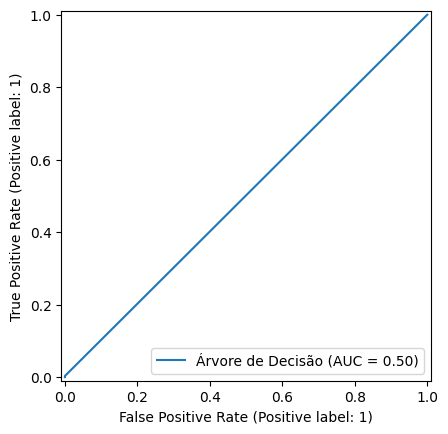

In [26]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão');

In [27]:
from sklearn.metrics import roc_auc_score

In [28]:
print(f'AUC Score: {roc_auc_score(y_val, y_previsto)}')

AUC Score: 0.5014970059880239


### Curva de Precisão x Recall

In [29]:
from sklearn.metrics import PrecisionRecallDisplay

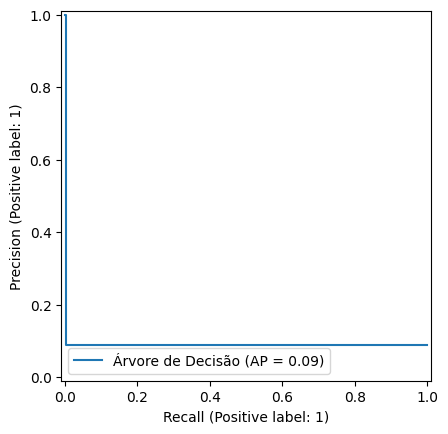

In [30]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão');

In [31]:
from sklearn.metrics import average_precision_score

In [32]:
print(f'AP Score: {average_precision_score(y_val, y_previsto)}')

AP Score: 0.0900073383413471


### Relatório de Métricas

In [33]:
from sklearn.metrics import classification_report

In [34]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     10479
           1       1.00      0.00      0.01      1002

    accuracy                           0.91     11481
   macro avg       0.96      0.50      0.48     11481
weighted avg       0.92      0.91      0.87     11481



## <font color='dark'>Validação cruzada</h1>

### Usando o KFold

A validação do modelo de classificação a partir da separação dos dados em conjunto de treino e validação faz com que o resultado seja muito dependente dessa divisão dos dados e pode ser que, de forma aleatória, o padrão dos dados de validação sejam diferentes do padrão dos dados de treinamento, levando a sorte de ter um resultado muito melhor do que a realidade ou o azar de um resultado muito pior do que a realidade.

Levando isso em consideração, é possível utilizar a **validação cruzada**, uma estratégia mais consistente e bem mais utilizada nos projetos de machine learning.

Na validação cruzada, ao invés de separarmos os dados em apenas treino e validação uma única vez, dividimos os dados em várias partes de mesmo tamanho. Em cada uma dessas divisões, será utilizada uma parte para validação e todas as outras para treinamento e o processo se repete até que todas as partes sejam utilizadas para validação e o restante para treinamento.

Será gerado um modelo para cada uma dessas divisões e a avaliação de desempenho será feita tirando a média da métrica de cada modelo. Isso faz com que a dependência da separação dos dados seja eliminada, já que há uma variação maior da escolha dos dados e é retirada uma média.

Geralmente são utilizadas 5 ou 10 partes, mais do que isso não é tão necessário porque necessita de um processamento maior e valores menores já mitiga o problema da escolha dos dados.

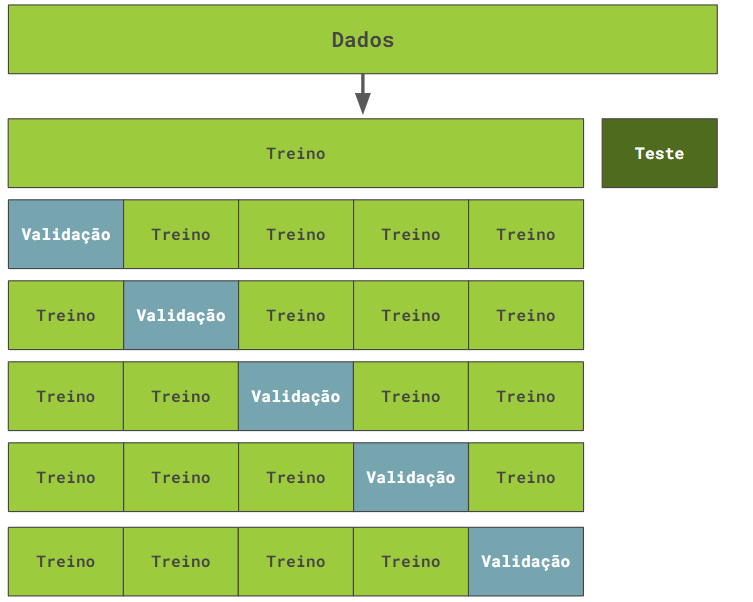

In [35]:
from sklearn.model_selection import cross_validate, KFold

In [38]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=kf)
cv_resultados

{'fit_time': array([0.44286919, 0.25922298, 0.24797416, 0.29123855, 0.25636911]),
 'score_time': array([0.00409746, 0.00397396, 0.00380397, 0.00375056, 0.00706244]),
 'test_score': array([0.91355471, 0.90810105, 0.90766551, 0.91332753, 0.89928136])}

In [39]:
cv_resultados['test_score']

array([0.91355471, 0.90810105, 0.90766551, 0.91332753, 0.89928136])

In [ ]:
media = cv_resultados['test_score'].min()
desvio_padrao = cv_resultados['test_score'].std()
print(f'Intervalo de Confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]') # Accuracy Model

Intervalo de Confiança: [0.8889033424064161, 0.9096593753636186]


### Validação cruzada com recall

In [41]:
def intervalo_conf(resultados):
    media = resultados['test_score'].min()
    desvio_padrao = resultados['test_score'].std()
    print(f'Intervalo de Confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]') # Accuracy Model

In [42]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring='recall')
cv_resultados

{'fit_time': array([0.56176186, 0.3134973 , 0.32569671, 0.41183853, 0.38071704]),
 'score_time': array([0.01788378, 0.01331997, 0.01395941, 0.0074892 , 0.0137732 ]),
 'test_score': array([0.02642008, 0.02227723, 0.0196802 , 0.01305483, 0.02427746])}

In [43]:
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.003823703223096893, 0.02228595735131564]


### Desafio

In [44]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv=kf, scoring = ['accuracy','recall', 'precision', 'f1'])
cv_resultados

{'fit_time': array([0.43057084, 0.29375362, 0.28370523, 0.29394269, 0.343086  ]),
 'score_time': array([0.0212009 , 0.02169371, 0.02564287, 0.04588938, 0.0309639 ]),
 'test_accuracy': array([0.91311922, 0.90777439, 0.90755662, 0.91343641, 0.89906359]),
 'test_recall': array([0.02774108, 0.01856436, 0.0196802 , 0.0156658 , 0.02427746]),
 'test_precision': array([0.25301205, 0.2173913 , 0.23529412, 0.22641509, 0.20192308]),
 'test_f1': array([0.05      , 0.03420753, 0.03632236, 0.02930403, 0.04334365])}

In [45]:
def relatorio_metricas(resultados):
    for metrica in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        media = resultados[metrica].mean()
        desvio_padrao = resultados[metrica].std()
        print(f'Intervalo de confiança({metrica}): [{media-2*desvio_padrao}, {min(media+2*desvio_padrao, 1.0)}]')

In [46]:
relatorio_metricas(cv_resultados)

Intervalo de confiança(test_accuracy): [0.8977713205030413, 0.9186087701234344]
Intervalo de confiança(test_recall): [0.012600239973077946, 0.0297713158080851]
Intervalo de confiança(test_precision): [0.1925521519039469, 0.2610621046761953]
Intervalo de confiança(test_f1): [0.024120625430194206, 0.0531504022353696]


### Estratificando os dados

In [47]:
dados['inadimplente'].value_counts(normalize=True)

inadimplente
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [48]:
from sklearn.model_selection import StratifiedKFold

In [49]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x, y, cv=skf, scoring='recall')

In [50]:
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.016542695264097764, 0.030838850870565575]


In [52]:
from imblearn.over_sampling import SMOTE

## <font color='dark'>Balanceamento dos dados</h1>

### Oversampling

In [53]:
oversample = SMOTE()
x_balanceado, y_balanceado = oversample.fit_resample(x, y)

In [54]:
y_balanceado.value_counts(normalize=True)

inadimplente
0    0.5
1    0.5
Name: proportion, dtype: float64

In [55]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x_balanceado, y_balanceado, cv=skf, scoring='recall')

In [56]:
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.706640306482482, 0.7460615902132117]


### Pipeline

In [57]:
from imblearn.pipeline import Pipeline as imbpipeline

In [59]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [60]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

In [61]:
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.18292844430889815, 0.26900663683966614]


### Undersamplig

In [62]:
from imblearn.under_sampling import NearMiss

In [63]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')

In [64]:
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.5731062360753766, 0.6653456990057719]


### Testando o modelo

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



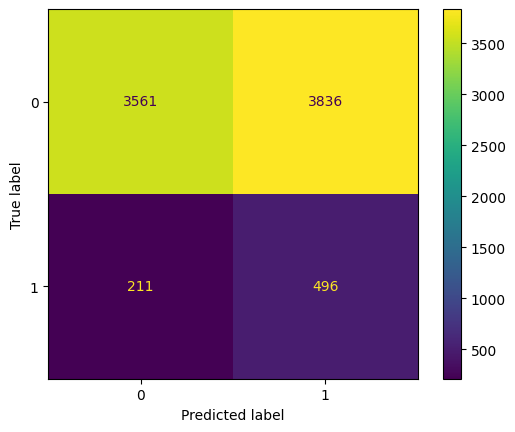

In [66]:
undersample = NearMiss(version=3)
x_balanceado, y_balanceado = undersample.fit_resample(x, y)

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_test)

print(classification_report(y_test, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto);

### Desafio

In [67]:
from imblearn.combine import SMOTEENN

In [68]:
modelo = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('smoteenn', SMOTEENN()), ('arvore', modelo)])

In [69]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, x, y, cv=skf, scoring = 'recall')
intervalo_conf(cv_resultados)

Intervalo de Confiança: [0.10478463241671324, 0.35905576658578053]
